> **BLOCKED — not part of the GCAM ambition ladder.** Refining is inert to the grid and CCS levers and was **not re-run on GCAM demand**. The only refinery run on disk is `REFINERY_REF`, solved on the old ~65 Mt MPP-flat demand, so every cell here resolves to that single old-demand run and the figures are **not GCAM-consistent** (and identical across scenarios). Pending a refinery run on GCAM demand. The cells below are left unexecuted for the ladder.


# Alumina refining

Refining is shown differently from smelting, and deliberately so. **The capture regime and the
inert anode rule are both smelter-side changes, and the grid patch leaves the refinery folder
untouched, so all twelve runs solve refining from byte-identical inputs.** Cumulative refining
emissions span 2.04 to 2.09 Gt across the twelve, a 2.8% spread, and the ordering is scrambled
with respect to the levers. That spread is the unseeded solver, not a scenario effect. See
choice 31.

So a three by four matrix would show twelve draws of the same problem. All twelve are drawn on
one axes instead, which is the honest presentation.

Refining technology names are `<boiler> + <calciner>`. Unabated is judged on emissions data,
not names: `MVR-Fossil-Boiler` is abated on intensity and `CST-Fossil-Boiler` by explicit
override, per choice 25.

In [1]:
import sys
import importlib
sys.path.append("../..")

import common
importlib.reload(common)   # pick up edits to common.py without restarting the kernel

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from common import (RUNS_INDEX, CCS_ORDER, CCS_LABELS, GRIDS, GRID_LABELS,
                    GRID_COLOURS, CAPTION, run_name, style, emissions, budget, production,
                    production_by_technology, intensity_split, process_emission_factors,
                    power_source, capture_grid, label_rows, add_caption, overlaid, year_axis, save)

style()
pd.set_option("display.width", 250)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [2]:
ALL = list(RUNS_INDEX)
refinery = {n: emissions(n, "refinery") for n in ALL}
limit = budget("refinery")
spread = pd.Series({n: s.sum() / 1000 for n, s in refinery.items()}).sort_values()
print("cumulative refining emissions, Gt")
print(spread.round(3).to_string())
print(f"\nrefining is inert to both the grid and the CCS lever, so every matrix cell "
      f"resolves to one canonical refining run (spread {spread.max() - spread.min():.3f} Gt).")

cumulative refining emissions, Gt
REMIND_none         2.04
REMIND_low          2.04
REMIND_high         2.04
REMIND_unlimited    2.04
MESSAGE_none        2.04
MESSAGE_low         2.04
MESSAGE_high        2.04
MESSAGE_unlimited   2.04
AIM_none            2.04
AIM_low             2.04
AIM_high            2.04
AIM_unlimited       2.04
WITCH_none          2.04
WITCH_low           2.04
WITCH_high          2.04
WITCH_unlimited     2.04

refining is inert to both the grid and the CCS lever, so every matrix cell resolves to one canonical refining run (spread 0.000 Gt).


## Annual refining emissions, all twelve runs

wrote figures/refining_emissions_annual.png and .svg


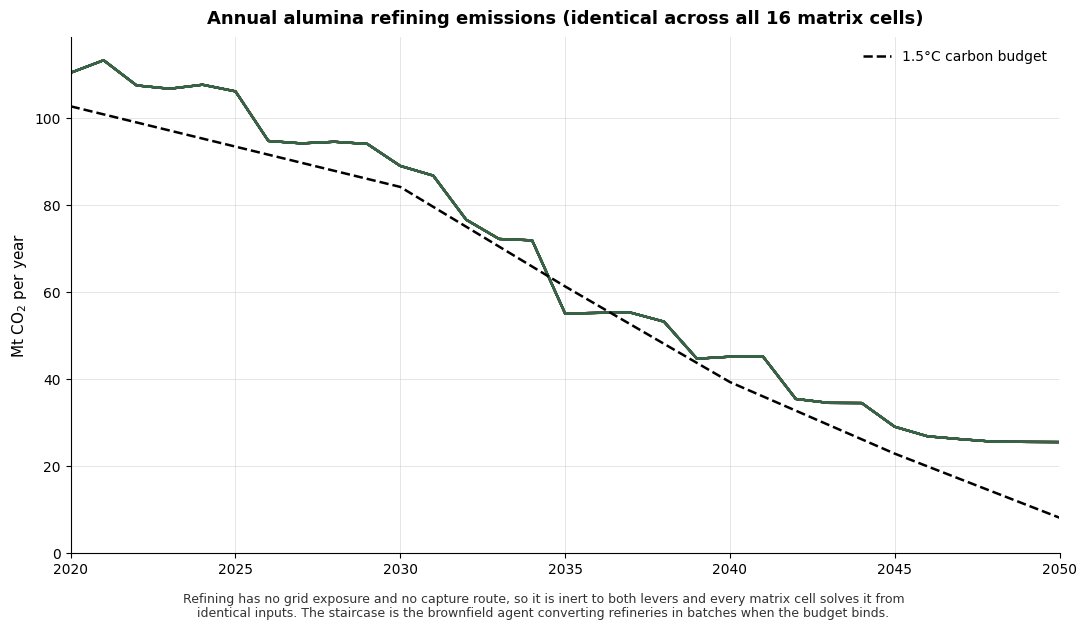

In [3]:
fig, ax = overlaid(figsize=(11, 6))
for n in ALL:
    r = RUNS_INDEX[n]
    ax.plot(refinery[n].index, refinery[n].values, color=GRID_COLOURS[r["grid"]],
            lw=1.6, alpha=0.75)
ax.plot(limit.index, limit.values, "k--", lw=1.8, label="1.5\u00b0C carbon budget")
ax.set_title("Annual alumina refining emissions (identical across all 16 matrix cells)")
ax.set_ylabel("Mt CO$_2$ per year")
year_axis(ax); ax.set_xticks(range(2020, 2051, 5)); ax.set_ylim(bottom=0)
ax.legend(loc="upper right", frameon=False)
fig.text(0.5, -0.04,
         "Refining has no grid exposure and no capture route, so it is inert to both levers and "
         "every matrix cell solves it from\nidentical inputs. The staircase is the brownfield "
         "agent converting refineries in batches when the budget binds.",
         ha="center", fontsize=9, color="#333333")
fig.tight_layout()
save(fig, "refining_emissions_annual")
plt.show()

## Digester technology, one panel per grid and anode combination

Capture does not appear because no refinery technology in MPP's table contains CCS.

wrote figures/refining_digester_technology.png and .svg


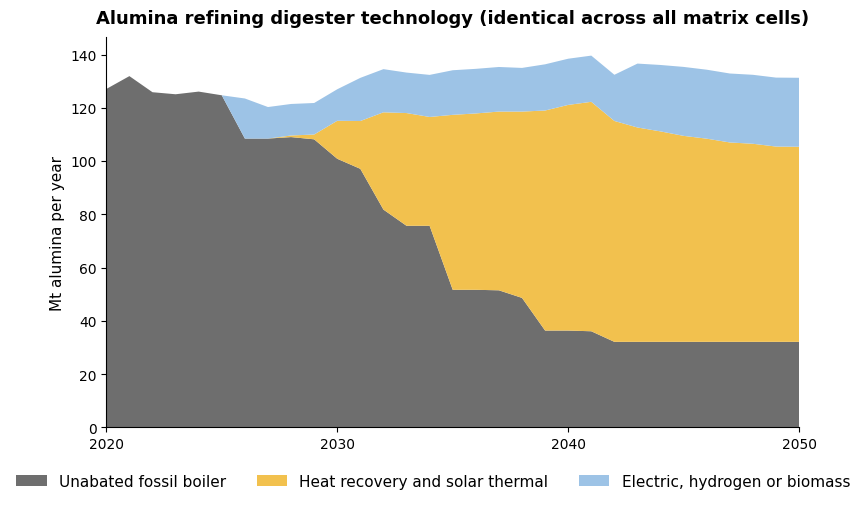

In [4]:
def boiler_group(technology):
    boiler = technology.split(" + ")[0]
    if boiler in ["Gas-Boiler", "Oil-Boiler", "Coal-Boiler"]:
        return "Unabated fossil boiler"
    if boiler in ["Elec-Boiler", "H2-Boiler", "Bio-Boiler"]:
        return "Electric, hydrogen or biomass"
    return "Heat recovery and solar thermal"

ORDER = ["Unabated fossil boiler", "Heat recovery and solar thermal", "Electric, hydrogen or biomass"]
COLOUR = dict(zip(ORDER, ["#6e6e6e", "#f2c14e", "#9dc3e6"]))

# Refining is inert to both levers, so it is one canonical run - a single panel, not a matrix.
name = run_name(GRIDS[0], CCS_ORDER[0])
df = production_by_technology(name, "refinery").copy()
df.columns = [boiler_group(c) for c in df.columns]
mix = df.T.groupby(level=0).sum().T
for g in ORDER:
    if g not in mix.columns:
        mix[g] = 0.0

fig, ax = plt.subplots(figsize=(8, 5))
ax.stackplot(mix.index, [mix[g].values for g in ORDER],
             colors=[COLOUR[g] for g in ORDER], labels=ORDER)
ax.set_title("Alumina refining digester technology (identical across all matrix cells)",
             fontsize=13, fontweight="bold")
ax.set_xlim(2020, 2050); ax.set_xticks([2020, 2030, 2040, 2050])
ax.grid(False); ax.set_ylim(bottom=0)
ax.set_ylabel("Mt alumina per year", fontsize=11)
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3, frameon=False, fontsize=11,
           bbox_to_anchor=(0.5, -0.02))
fig.tight_layout(rect=[0, 0.05, 1, 1])
save(fig, "refining_digester_technology")
plt.show()